In [1]:
!pip install keras keras-hub --upgrade -q
import os
os.environ["KERAS_BACKEND"] = "jax"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.21.1 requires keras-hub==0.21.1, but you have keras-hub 0.23.0 which is incompatible.


In [2]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

In [3]:
from keras.datasets import cifar10

# Load the dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


In [4]:
import keras
from keras import layers

# Model to mirror LeNet architecture

model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.ZeroPadding2D(padding=2),
    layers.Conv2D(32, (5, 5),activation='sigmoid'),
    layers.MaxPooling2D((2, 2)),

    layers.ZeroPadding2D(padding=0),
    layers.Conv2D(64, (5, 5), activation='sigmoid'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(120, activation='sigmoid'),
    layers.Dense(84, activation='sigmoid'),
    layers.Dense(10, activation='softmax')
])

In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ zero_padding2d (ZeroPadding2D)  │ (None, 36, 36, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d_1                │ (None, 16, 16, 32)     │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │       276,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 341,310 (1.30 MB)

 Trainable params: 341,310 (1.30 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
opt = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model.compile(
    optimizer= opt,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [7]:
x_val = x_train[-5000:]
y_val = y_train[-5000:]
x_train = x_train[:45000]
y_train = y_train[:45000]

In [8]:
y_val[2]

array([4], dtype=uint8)

In [9]:
y_train.shape

(45000, 1)

In [10]:
history = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_data=(x_val, y_val),
    validation_batch_size=128
)

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 135s 187ms/step - accuracy: 0.1612 - loss: 2.1940 - val_accuracy: 0.1606 - val_loss: 2.2965
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 128s 182ms/step - accuracy: 0.2611 - loss: 1.9651 - val_accuracy: 0.3238 - val_loss: 1.8403
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 127s 181ms/step - accuracy: 0.3463 - loss: 1.7758 - val_accuracy: 0.3432 - val_loss: 1.7375
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 128s 181ms/step - accuracy: 0.3768 - loss: 1.6888 - val_accuracy: 0.4052 - val_loss: 1.6327
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 128s 182ms/step - accuracy: 0.4041 - loss: 1.6253 - val_accuracy: 0.4148 - val_loss: 1.5815
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 128s 182ms/step - accuracy: 0.4342 - loss: 1.5420 - val_accuracy: 0.4496 - val_loss: 1.5000
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 128s 181ms/step - accuracy: 0.4465 - loss: 1.5071 - val_accuracy: 0.4616 - val_loss: 1.4559
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 127s 181ms/step - accuracy: 0.4705 -

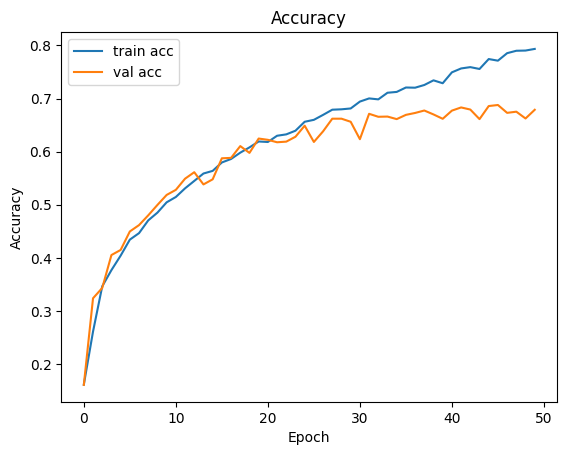

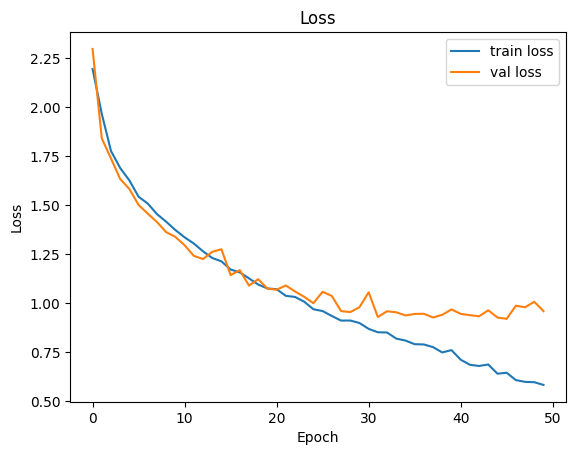

In [11]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [13]:
new_model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.ZeroPadding2D(padding=2),
    layers.Conv2D(32, (5, 5),activation='sigmoid'),
    layers.MaxPooling2D((2, 2)),

    layers.ZeroPadding2D(padding=0),
    layers.Conv2D(64, (5, 5), activation='sigmoid'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(120, activation='sigmoid'),
    layers.Dense(84, activation='sigmoid'),
    layers.Dense(10, activation='softmax')
])

opt = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
new_model.compile(
    optimizer= opt,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

new_history = new_model.fit(
    x_train,
    y_train,
    epochs=25,
    batch_size=64,
    validation_data=(x_val, y_val),
    validation_batch_size=128
)

Epoch 1/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 193ms/step - accuracy: 0.1580 - loss: 2.1981 - val_accuracy: 0.1988 - val_loss: 2.0858
Epoch 2/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 130s 185ms/step - accuracy: 0.2646 - loss: 1.9436 - val_accuracy: 0.3318 - val_loss: 1.8417
Epoch 3/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 131s 186ms/step - accuracy: 0.3503 - loss: 1.7527 - val_accuracy: 0.3710 - val_loss: 1.6848
Epoch 4/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 130s 185ms/step - accuracy: 0.3826 - loss: 1.6702 - val_accuracy: 0.4100 - val_loss: 1.6102
Epoch 5/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 131s 186ms/step - accuracy: 0.4110 - loss: 1.5912 - val_accuracy: 0.4198 - val_loss: 1.6033
Epoch 6/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 131s 186ms/step - accuracy: 0.4391 - loss: 1.5250 - val_accuracy: 0.4684 - val_loss: 1.4645
Epoch 7/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 131s 186ms/step - accuracy: 0.4599 - loss: 1.4713 - val_accuracy: 0.4840 - val_loss: 1.4069
Epoch 8/25
704/704 ━━━━━━━━━━━━━━━━━━━━ 130s 185ms/step - accuracy: 0.4825 -

In [14]:
#output model

new_model.save('CNN_cifar10_06576_LeNet.keras')